# Training Curves — Convergence vs Overfitting

Two characteristic examples:

1. **Healthy convergence** — Swin-T / ImageNet V1 / stage4 / fold4 (late convergence, small decline)
2. **Overfitting** — ResNet-18 / ImageNet V1 / layer3 / fold1 (early peak, aggressive loss drop, large val regression)

Each plot:
- Left Y axis: train_loss (red)
- Right Y axis: val_mIoU (navy)
- Green vertical line: best mIoU point

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import mlflow
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 150

mlflow.set_tracking_uri(str(PROJECT_ROOT / "mlruns"))
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("woodland-fss")

FIGURES_DIR = PROJECT_ROOT / "figures" / "training_curves"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"MLflow: {mlflow.get_tracking_uri()}")
print(f"Figures: {FIGURES_DIR}")

MLflow: /home/zehra/Desktop/woodland/mlruns
Figures: /home/zehra/Desktop/woodland/figures/training_curves


In [2]:
def find_run(target_name):
    """Returns the most recent train run with the given name."""
    runs = client.search_runs(
        [exp.experiment_id],
        filter_string=f"params.phase = 'train' and tags.mlflow.runName = '{target_name}'",
    )
    if not runs:
        all_runs = client.search_runs([exp.experiment_id], max_results=500)
        runs = [r for r in all_runs if r.info.run_name == target_name]
    if not runs:
        raise ValueError(f"Run not found: {target_name}")
    return max(runs, key=lambda r: r.info.start_time)


def get_curves(run_id):
    loss_hist = client.get_metric_history(run_id, "train_loss")
    miou_hist = client.get_metric_history(run_id, "val_mIoU")
    loss = sorted([(m.step, m.value) for m in loss_hist])
    miou = sorted([(m.step, m.value) for m in miou_hist])
    return np.array(loss), np.array(miou)


def plot_curve(run_name, title, save_name):
    run = find_run(run_name)
    loss, miou = get_curves(run.info.run_id)

    fig, ax1 = plt.subplots(figsize=(8, 4.5))

    color_loss = "#c0392b"
    color_miou = "#2c3e50"

    ax1.set_xlabel("Episode", fontsize=11)
    ax1.set_ylabel("Training Loss", color=color_loss, fontsize=11)
    line_loss, = ax1.plot(loss[:, 0], loss[:, 1], color=color_loss, linewidth=1.8, label="Training Loss")
    ax1.tick_params(axis="y", labelcolor=color_loss)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.set_ylabel("Validation mIoU", color=color_miou, fontsize=11)
    line_miou, = ax2.plot(miou[:, 0], miou[:, 1], color=color_miou, linewidth=1.8,
                          marker="o", markersize=3, label="Validation mIoU")
    ax2.tick_params(axis="y", labelcolor=color_miou)

    # Mark best mIoU
    best_idx = miou[:, 1].argmax()
    best_ep = miou[best_idx, 0]
    best_val = miou[best_idx, 1]
    line_best = ax2.axvline(best_ep, color="green", linestyle="--", alpha=0.7,
                            label=f"Best (ep={int(best_ep)}, mIoU={best_val:.3f})")

    # Small legend in upper right corner (inside axes, no overflow)
    ax2.legend(handles=[line_loss, line_miou, line_best],
               loc="upper right",
               fontsize=7, framealpha=0.9, edgecolor="gray",
               handlelength=1.5, borderpad=0.4, labelspacing=0.3)

    plt.title(title, fontsize=12, fontweight="bold")
    plt.tight_layout()

    save_path = FIGURES_DIR / f"{save_name}.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
    return loss, miou

## Healthy Convergence: Swin-T / stage4 / fold4

Peak: episode 26000, mIoU=0.508. Train loss and val mIoU in sync, decline +0.020 (noise level).

Saved: /home/zehra/Desktop/woodland/figures/training_curves/curve_healthy_swint_stage4_fold4.png


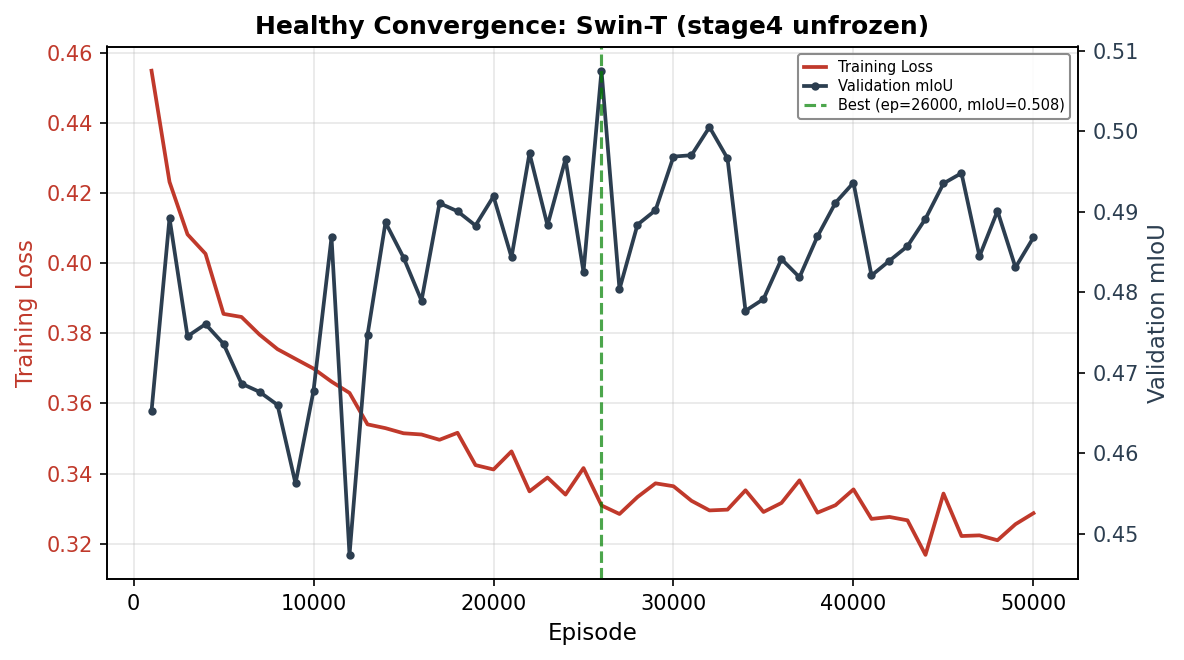

In [3]:
plot_curve(
    run_name="ProtoNet_SwinT_ImageNetV1_stage4_fold4_seed-42",
    title="Healthy Convergence: Swin-T (stage4 unfrozen)",
    save_name="curve_healthy_swint_stage4_fold4",
);

## Overfitting: ResNet-18 / layer3 / fold1

Peak: episode 1000 (very early), mIoU=0.448. Train loss drops aggressively (50% reduction), val mIoU regresses +0.091 from peak — classic overfit.

Saved: /home/zehra/Desktop/woodland/figures/training_curves/curve_overfit_resnet18_layer3_fold1.png


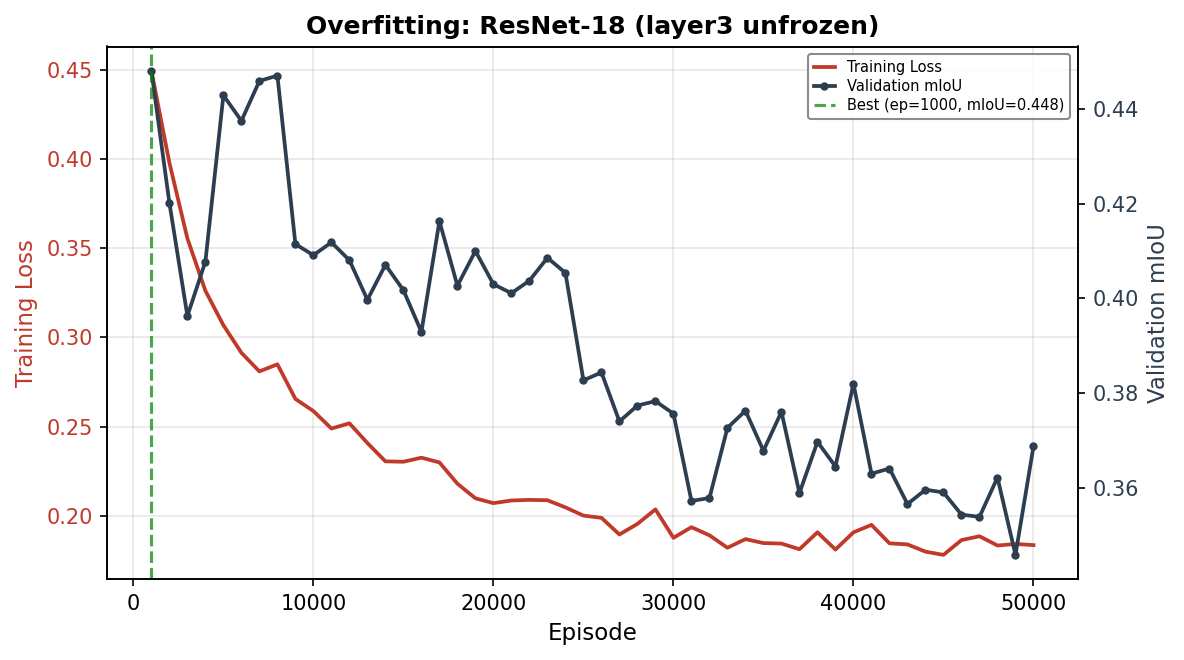

In [4]:
plot_curve(
    run_name="ProtoNet_ResNet18_layer3_fold1_seed-42",
    title="Overfitting: ResNet-18 (layer3 unfrozen)",
    save_name="curve_overfit_resnet18_layer3_fold1",
);

## Cross-Fold Variance

Distribution of test fgIoU values across folds for all configurations (backbone x unfreeze x pretrained).

In [5]:
from collections import defaultdict

# Fetch all test runs (V1 — most recent for duplicates)
all_test_runs = client.search_runs(
    [exp.experiment_id],
    filter_string="params.phase = 'test'",
    max_results=500,
)

by_name = defaultdict(list)
for r in all_test_runs:
    by_name[r.info.run_name].append(r)
v1_test_runs = [max(rlist, key=lambda x: x.info.start_time) for rlist in by_name.values()]

# Extract fold and fgIoU for each run
fold_values = {0: [], 1: [], 2: [], 3: [], 4: []}
for r in v1_test_runs:
    name = r.info.run_name
    # ...fold0_seed-42 → find fold number
    for i in range(5):
        if f"_fold{i}_" in name:
            fg = r.data.metrics.get("test_fgIoU")
            if fg is not None:
                fold_values[i].append(fg)
            break

# Summary
for i in range(5):
    arr = np.array(fold_values[i])
    print(f"Fold {i}: n={len(arr)}, mean={arr.mean():.3f}, std={arr.std():.3f}, "
          f"median={np.median(arr):.3f}, min={arr.min():.3f}, max={arr.max():.3f}")

Fold 0: n=18, mean=0.453, std=0.025, median=0.456, min=0.394, max=0.489
Fold 1: n=18, mean=0.580, std=0.027, median=0.582, min=0.541, max=0.656
Fold 2: n=18, mean=0.425, std=0.033, median=0.416, min=0.383, max=0.486
Fold 3: n=18, mean=0.495, std=0.038, median=0.501, min=0.436, max=0.551
Fold 4: n=18, mean=0.527, std=0.038, median=0.528, min=0.430, max=0.621


Saved: /home/zehra/Desktop/woodland/figures/training_curves/fold_variance_boxplot.png


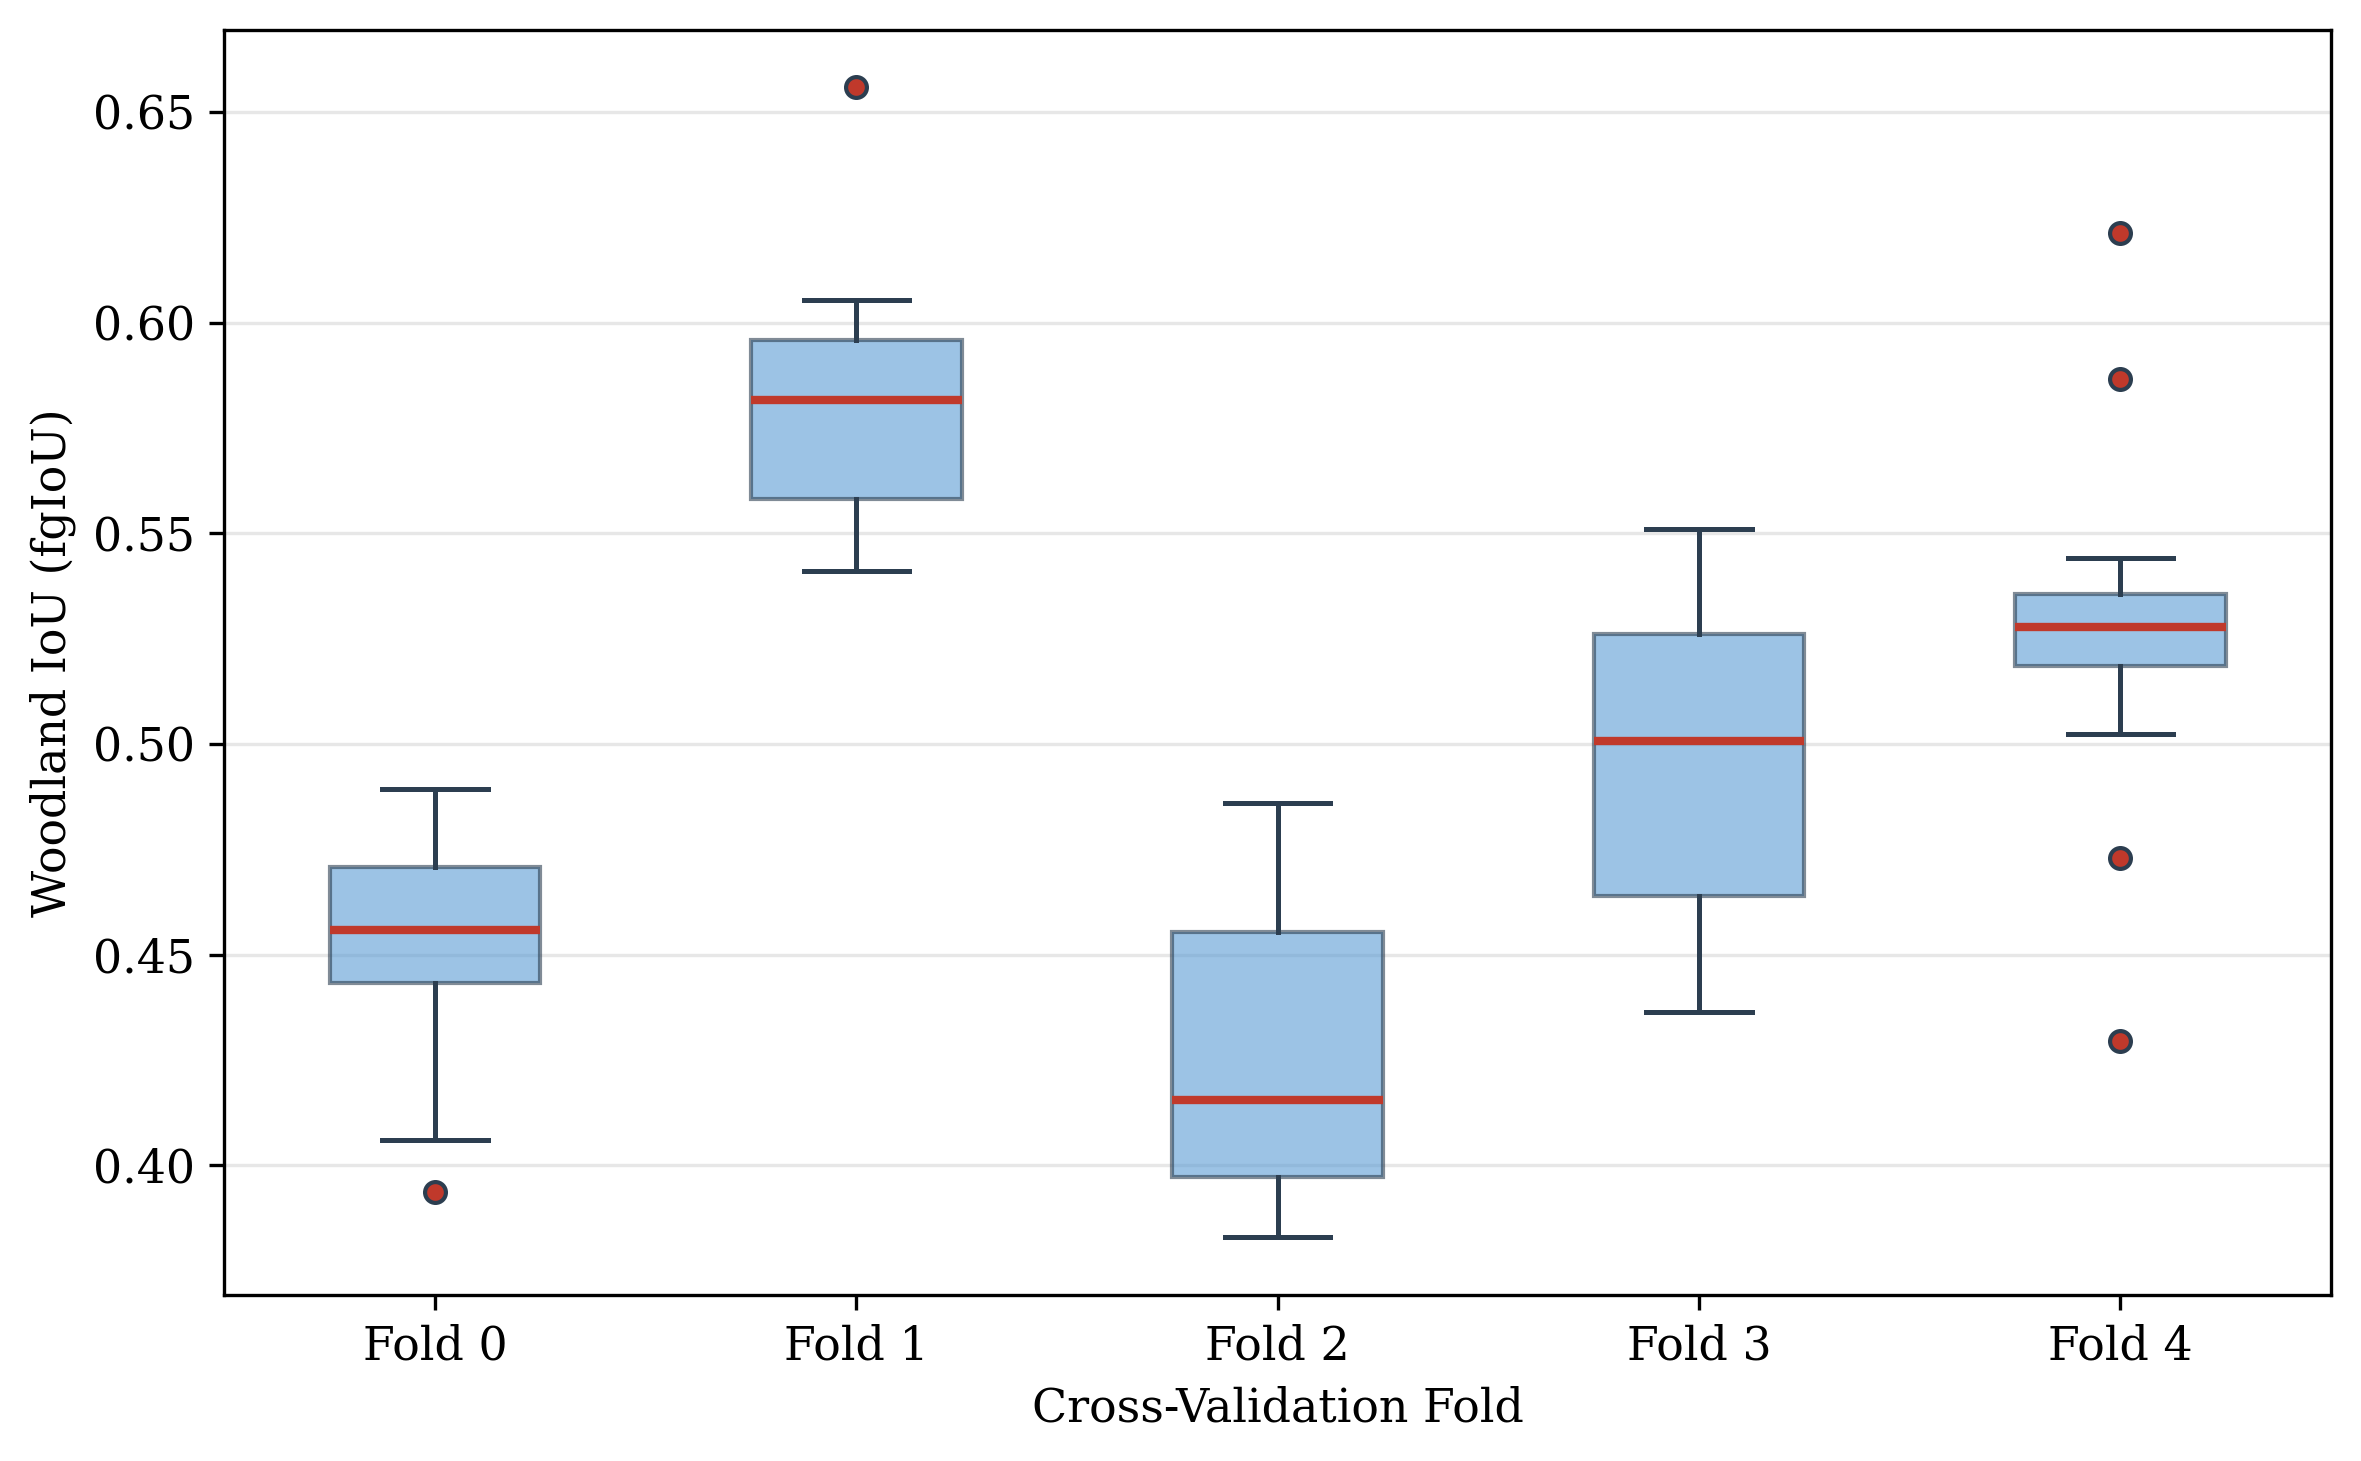

In [6]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

data = [fold_values[i] for i in range(5)]
labels = [f"Fold {i}" for i in range(5)]

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="#c0392b", linewidth=2),
    boxprops=dict(facecolor="#5a9bd4", alpha=0.6, edgecolor="#2c3e50"),
    whiskerprops=dict(color="#2c3e50", linewidth=1.2),
    capprops=dict(color="#2c3e50", linewidth=1.2),
    flierprops=dict(marker="o", markersize=5, markerfacecolor="#c0392b",
                    markeredgecolor="#2c3e50"),
)

ax.set_xlabel("Cross-Validation Fold", fontsize=11)
ax.set_ylabel("Woodland IoU (fgIoU)", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()

save_path = FIGURES_DIR / "fold_variance_boxplot.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

# Reset font
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10